In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os


In [8]:
# Télécharger population si pas déjà présent
if not os.path.exists("data/raw/population_communes.xlsx"):
    from src.fetch_population import download_population
    download_population()

# Télécharger élections si pas déjà présent
if not os.path.exists("data/raw/elections_legislatives.xlsx"):
    from src.fetch_elections import download_elections
    download_elections()

# Télécharger élections 1er tour
if not os.path.exists("data/raw/elections_t1_legislatives.xlsx"):
    from src.fetch_elections_t1 import download_elections
    download_elections()


Téléchargement en cours : https://static.data.gouv.fr/resources/elections-legislatives-des-12-et-19-juin-2022-resultats-du-1er-tour/20220613-095205/resultats-par-niveau-subcom-t1-france-entiere.xlsx
✔️ Fichier téléchargé avec succès : data/raw/elections_t1_legislatives.xlsx


In [9]:
# Charger population
df_pop = pd.read_excel("data/raw/population_communes.xlsx")

# Charger élections
df_ele = pd.read_excel("data/raw/elections_legislatives.xlsx")

# Elections 1er tour
df_ele1 = pd.read_excel("data/raw/elections_t1_legislatives.xlsx")

# Vérification
print("Population :")
display(df_pop.head())

print("Élections :")
display(df_ele.head())

print("Elections_t1")
display(df_ele1.head())

Population :


,objectid,reg,dep,cv,codgeo,libgeo,p13_pop,p14_pop,p15_pop,p16_pop,p17_pop,p18_pop,p19_pop,p20_pop,p21_pop
0,115658,52,85,8502,85062,Châteauneuf,968.0,993.0,1013.0,1027.0,1056,1085.0,1114.0,1118.0,1134.0
1,115659,26,58,5808,58300,Urzy,1839.0,1835.0,1828.0,1802.0,1775,1749.0,1746.0,1747.0,1742.0
2,115660,43,70,7012,70137,Chassey-lès-Montbozon,218.0,217.0,216.0,215.0,217,215.0,215.0,220.0,225.0
3,115661,21,51,5123,51649,Vitry-le-François,13174.0,13144.0,12805.0,12552.0,12133,11743.0,11376.0,11458.0,11454.0
4,115662,11,78,7811,78638,Vaux-sur-Seine,4749.0,4715.0,4788.0,4857.0,4927,4929.0,5010.0,5020.0,5083.0


Élections :


,Code du département,Libellé du département,Code de la circonscription,Libellé de la circonscription,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,...,Unnamed: 187,Unnamed: 188,Unnamed: 189,Unnamed: 190,Unnamed: 191,Unnamed: 192,Unnamed: 193,Unnamed: 194,Unnamed: 195,Unnamed: 196
0,01,Ain,1,1ère circonscription,16,Arbigny,Complet,327,154,47.09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01,Ain,1,1ère circonscription,24,Attignat,Complet,2454,1281,52.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01,Ain,1,1ère circonscription,29,Beaupont,Complet,446,224,50.22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01,Ain,1,1ère circonscription,38,Bény,Complet,604,306,50.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01,Ain,1,1ère circonscription,40,Béréziat,Complet,362,179,49.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Elections_t1


,Code du département,Libellé du département,Code de la circonscription,Libellé de la circonscription,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,...,Unnamed: 187,Unnamed: 188,Unnamed: 189,Unnamed: 190,Unnamed: 191,Unnamed: 192,Unnamed: 193,Unnamed: 194,Unnamed: 195,Unnamed: 196
0,01,Ain,1,1ère circonscription,16,Arbigny,Complet,327,154,47.09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01,Ain,1,1ère circonscription,24,Attignat,Complet,2454,1281,52.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01,Ain,1,1ère circonscription,29,Beaupont,Complet,446,224,50.22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01,Ain,1,1ère circonscription,38,Bény,Complet,604,306,50.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01,Ain,1,1ère circonscription,40,Béréziat,Complet,362,179,49.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Élections : garder uniquement code département, code commune et exprimés
df_ele_clean = df_ele[['Code du département', 'Code de la commune', 'Exprimés']].copy()

# Créer le code INSEE complet à 5 chiffres
df_ele_clean['code_commune'] = df_ele_clean['Code du département'].astype(str).str.zfill(2) + \
                               df_ele_clean['Code de la commune'].astype(str).str.zfill(3)

# Garder uniquement code_commune et voix
df_ele_clean = df_ele_clean[['code_commune', 'Exprimés']]
df_ele_clean.columns = ['code_commune', 'voix']

print("Élections nettoyées :")
display(df_ele_clean.head())

# Population : garder codgeo et p13_pop
df_pop_clean = df_pop[['codgeo', 'p13_pop']].copy()
df_pop_clean.columns = ['code_commune', 'population']

# Convertir code_commune en string avec 5 chiffres
df_pop_clean['code_commune'] = df_pop_clean['code_commune'].astype(str).str.zfill(5)

print("Population nettoyée :")
display(df_pop_clean.head())


Élections nettoyées :


,code_commune,voix
0,01016,146
1,01024,1100
2,01029,195
3,01038,275
4,01040,162


Population nettoyée :


,code_commune,population
0,85062,968.0
1,58300,1839.0
2,70137,218.0
3,51649,13174.0
4,78638,4749.0


In [10]:
# Colonnes fixes pour localisation
loc_cols = ['Code du département','Code de la commune','Code de la circonscription']

# Colonnes des partis et voix : colonnes Z/AA, AH/AI, AP/AQ, ...
# On les transforme en long format automatiquement
parti_cols = [
    ('Z','AA'), ('AH','AI'), ('AP','AQ'), ('AX','AY'), ('BF','BG'),
    ('BN','BO'), ('BV','BW'), ('CD','CE'), ('CL','CM'), ('CT','CU'),
    ('DB','DC'), ('DJ','DK'), ('DR','DS'), ('DZ','EA'), ('EH','EI'),
    ('EP','EQ'), ('EX','EY'), ('FF','FG'), ('FN','FO'), ('FV','FW'),
    ('GD','GE'), ('GL','GM')
]

rows = []
for idx, row in df_ele1.iterrows():
    code_dept = str(row['Code du département']).zfill(2)
    code_com = str(row['Code de la commune']).zfill(3)
    code_circ = str(row['Code de la circonscription']).zfill(2)
    for col_parti, col_voix in parti_cols:
        parti = row.get(col_parti)
        voix = row.get(col_voix)
        if pd.notna(parti) and pd.notna(voix) and voix > 0:
            rows.append({
                'code_departement': code_dept,
                'code_commune': code_com,
                'code_circonscription': code_circ,
                'parti': parti,
                'voix': voix
            })

df_ele1_long = pd.DataFrame(rows)


In [5]:
# Merge sur code_commune
df_merged = df_ele_clean.merge(df_pop_clean, on='code_commune', how='left')

# Vérifier les NaN
print("Nombre de NaN dans population :", df_merged['population'].isna().sum())
print("Nombre de NaN dans voix :", df_merged['voix'].isna().sum())

# Supprimer les lignes avec NaN dans population
df_merged = df_merged.dropna(subset=['population', 'voix'])
print("Après suppression des NaN :", len(df_merged))

# Vérifier le merge
df_merged.head()


Nombre de NaN dans population : 463
Nombre de NaN dans voix : 0
Après suppression des NaN : 34862


,code_commune,voix,population
0,01016,146,427.0
1,01024,1100,3260.0
2,01029,195,677.0
3,01038,275,718.0
4,01040,162,470.0


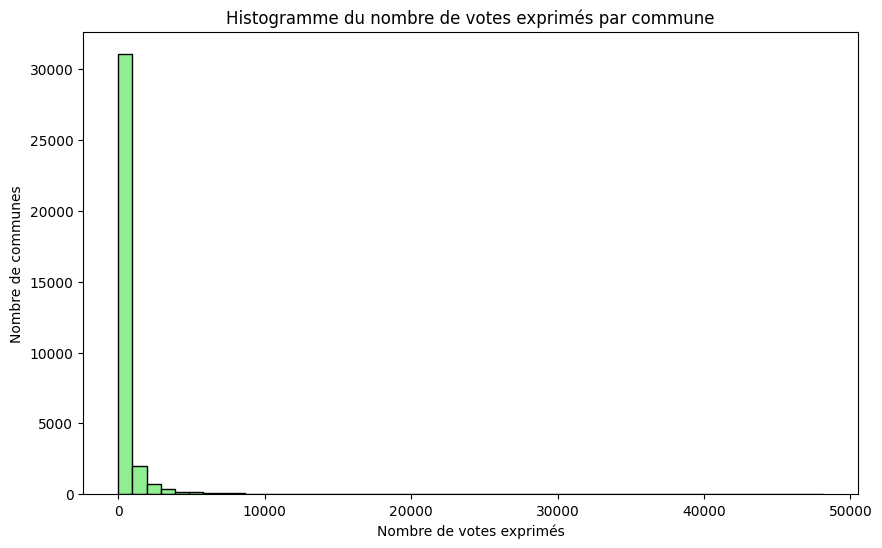

In [6]:
plt.figure(figsize=(10,6))
plt.hist(df_merged['voix'], bins=50, color='lightgreen', edgecolor='black')
plt.xlabel("Nombre de votes exprimés")
plt.ylabel("Nombre de communes")
plt.title("Histogramme du nombre de votes exprimés par commune")
plt.show()


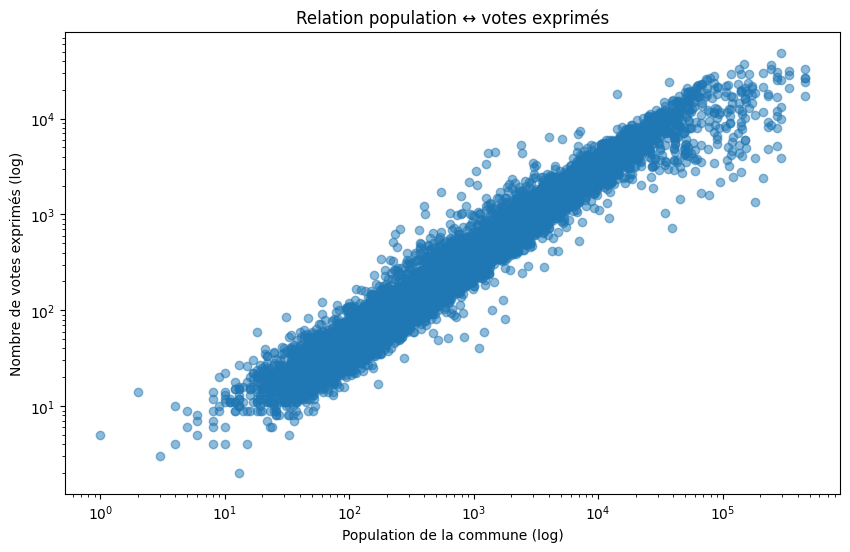

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(df_merged['population'], df_merged['voix'], alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Population de la commune (log)")
plt.ylabel("Nombre de votes exprimés (log)")
plt.title("Relation population ↔ votes exprimés")
plt.show()
